# Multiple linear regression for the advertising dataset

This [Advertising dataset](https://raw.githubusercontent.com/nguyen-toan/ISLR/master/dataset/Advertising.csv), originally featured in [An Introduction to Statistical Learning](https://www.statlearning.com/), contains sales data for a product across 200 different markets, along with advertising budgets (in thousands of dollars) allocated to TV, radio, and newspaper campaigns in each market.

Last time, we performed simple linear regression analyses. That is, for each analysis, we have ONE dependent variable and ONE independent variable. The OLS model can also be used for multiple independent variables.

In [1]:
# Load the Advertising dataset
import pandas as pd
url = "https://raw.githubusercontent.com/nguyen-toan/ISLR/master/dataset/Advertising.csv"
ad_df = pd.read_csv(url)

from statsmodels.formula.api import ols

# Sales is the dependent (output) variable
ad_model = ols(formula='Sales ~ TV + Radio + Newspaper', data=ad_df).fit()

# Show a summary of the model
ad_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.58e-96
Time:                        18:38:43   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.9389      0.312      9.422      0.000       2.324       3.554
TV             0.0458      0.001     32.809      0.000       0.043       0.049
Radio          0.1885      0.009     21.893      0.000       0.172       0.206
Newspaper     -0.0010      0.006     -0.177      0.860      -0.013       0.011
==============================================================================
Omnibus:                       60.414   Durbin-Watson:                   2.084
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              151.241
Skew:                          -1.327   Prob(JB):                     1.44e-33
Kurtosis:                       6.332   Cond. No.                         454.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

*  R-Squared: 0.897. About 89.7About 89.7% of the variation in Sales is explained by the predictors (TV, Radio, Newspaper). This is very high, suggesting a strong model fit.
*  F-statistic: 570.3, Prob(F-statistic): 1.58e-96 Both indicate highly significant, meaning at least one predictor is strongly related to Sales.
*  Intercept coef: 2.9389. When TV, Radio, Newspaper advertisement budgets are all 0, predicted Sales would be 2.9389.
*  TV coef: 0.0458. Assuming no change in Radio and Newspaper budget, for each additional 1K on TV ads, Sales would increase 0.0458 **thousand units**, i.e. 45.80 units.
*  Radio coef: 0.1885. Assuming no change in TV and Newspaper budget, for each additional 1K on Radio ads, Sales would increase 0.1885 **thousand units**, i.e. 188.50 units.
*  Newspaper coef: -0.0010. Effect is negligible and not significant (p = 0.860)

These coefficients form a formula to calculate fitted sales based on ads budgets:

$$
\text{Fitted Sales} = 2.9389 + 0.0458 \times TV + 0.1885 \times Radio - 0.0010 \times Newspaper
$$


In [2]:
ad_df["Fitted_Sales"] = ad_model.fittedvalues
ad_df[['Sales', 'Fitted_Sales']].head()

,Sales,Fitted_Sales
0,22.1,20.523974
1,10.4,12.337855
2,9.3,12.307671
3,18.5,17.597830
4,12.9,13.188672


We can see that this multiple linear regression model does a better job predicting sales than the simple linear regression models we created before.

It is hard to visualize a linear regression model when there are multiple independent variables. However, we can use a scatter plot to visualize the relationship between the actual Sales and the fitted sales.

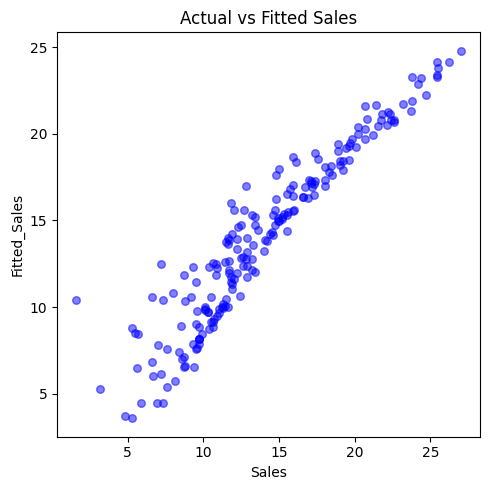

In [3]:
import matplotlib.pyplot as plt
ad_df["Fitted_Sales"] = ad_model.fittedvalues
# Plot Actual vs Predicted
ad_df.plot(kind='scatter',    #Indicate the kind of plot to be generated
        x='Sales',                  #Identify the column for the x-axis
        y='Fitted_Sales',           #Identify the column for the y_axis
        figsize=(5, 5),             #Set up the width and height of the graph
        title='Actual vs Fitted Sales',    #Set up the title of the graph
        s=30,                       #Indicate the size of each dot
        alpha=0.5,                  #Indicate the level of transparency
        color='blue'                #Indicate the color for the dots
        )

plt.tight_layout()
plt.show()



The above scatter plot shows consistency between actual and fitted sales - many of the dots are near a 45-degree line. The distance between each dot and a perfect 45-degree line is an error/residual. The model also keeps track of the residuals for all rows.

In [4]:
ad_df['Residuals'] = ad_model.resid
ad_df[['Sales', 'Fitted_Sales', 'Residuals']].head()

,Sales,Fitted_Sales,Residuals
0,22.1,20.523974,1.576026
1,10.4,12.337855,-1.937855
2,9.3,12.307671,-3.007671
3,18.5,17.597830,0.902170
4,12.9,13.188672,-0.288672


We can see from the above results that residuals are created by Sales - Fitted_Sales. Another useful visualization is to plot residuals against fitted values.

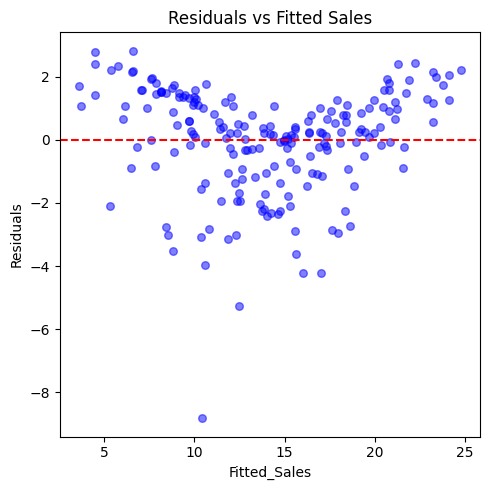

In [5]:
import matplotlib.pyplot as plt

# Plot Actual vs Predicted
ad_df.plot(kind='scatter',    #Indicate the kind of plot to be generated
        x='Fitted_Sales',                  #Identify the column for the x-axis
        y='Residuals',           #Identify the column for the y_axis
        figsize=(5, 5),             #Set up the width and height of the graph
        title='Residuals vs Fitted Sales',    #Set up the title of the graph
        s=30,                       #Indicate the size of each dot
        alpha=0.5,                  #Indicate the level of transparency
        color='blue'                #Indicate the color for the dots
        )

plt.axhline(0, color='red', linestyle='--') # a horizontal line at 0
plt.tight_layout()
plt.show()



We can see a clear curved (U-shaped) structure in the above plot.

*  Residuals are mostly positive at low fitted values. That is, the model under predicted.
*  Residuals become mostly negative in the middle range. That is, the model over predicted.
*  Residuals trend positive again at high fitted values. That is, the model under predicted again.

The curved pattern in the residuals vs fitted plot suggests the relationship is not fully linear and that the model is systematically under and over predicting in different regions.

We knew from last time that TV ads was a key predictor for Sales. We can also create a scatter plot to show residuals against TV ads.

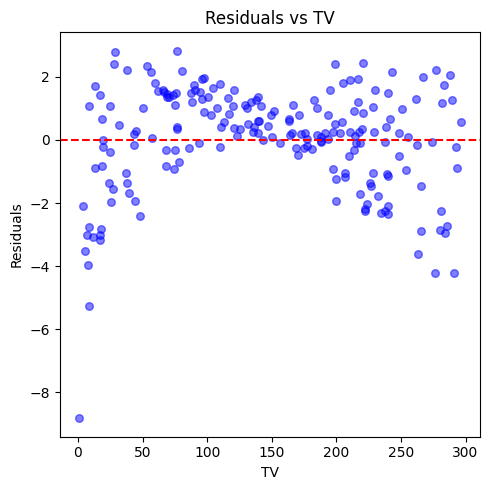

In [ ]:
import matplotlib.pyplot as plt

# Plot Actual vs Predicted
ad_df.plot(kind='scatter',    #Indicate the kind of plot to be generated
        x='TV',                  #Identify the column for the x-axis
        y='Residuals',           #Identify the column for the y_axis
        figsize=(5, 5),             #Set up the width and height of the graph
        title='Residuals vs TV',    #Set up the title of the graph
        s=30,                       #Indicate the size of each dot
        alpha=0.5,                  #Indicate the level of transparency
        color='blue'                #Indicate the color for the dots
        )

plt.axhline(0, color='red', linestyle='--') # a horizontal line at 0
plt.tight_layout()
plt.show()



Just like your residuals vs fitted plot, this one is not random. What we see clearly:

*  Low TV spending (near 0 - 50): Many negative residuals. The model over predicts sales for low TV spenders
*  Mid-range TV spending (around 100-180): Residuals cluster closer to 0. The model performs best here.
*  High TV spending (200-300): Residuals trend negative again. Over prediction returns, and variance increases.

The model assumes that each additional dollar spent on TV increases sales by the same amount. But this plot suggests that TV ads are more effective in the middle range and less effective at very low or very high spending levels.

# The scikit-learn datasets

Scikit-learn is one of the most popular open-source machine learning libraries in Python. It was first released in 2010 and is widely used in academia and industry. Check out the [scikit-learn datasets](https://scikit-learn.org/stable/datasets.html).

**Add a text block** to write down your thoughts about some of the datasets that might be of interest to you.

# Practice with a diabetes dataset

One of the "toy" datasets supported by scikit-learn is a [diabetes dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset).

The following code block loads the dataset and then converts the 10 numeric predictors into a DataFrame.

In [ ]:
import pandas as pd

# Load data from sklearn
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()

# Convert the data portion to a DataFrame object
diabetes_df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# Add the target portion to
diabetes_df['target'] = diabetes.target

# Show some information about the dataset
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


There are 11 columns and 442 rows in the dataset. Each row represent a patient. The `target` column measures how severe a patient's diabetes has become over one year. The other 10 columns measure some baseline data about each patient:
*  Demographics
   *  age: Age of the patient
   *  sex: Biological sex
*  Body measurements
   *  bmi: Body mass index
   *  bp: Average blood pressure
*  Blood serum measurements
   *  s1: Total serum cholesterol
   *  s2: Low density lipoproteins (LDL)
   *  s3: High density lipoproteins (HDL)
   *  s4: Total cholesterol / HDL
   *  s5: Log of serum triglycerides
   *  s6: Blood sugar level

## Initial data inspection & exploration

Perform initial data exploration using skills we learned before. No need for visualization yet. Add code blocks as needed.

In [ ]:
diabetes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [ ]:
pd.options.display.float_format = '{:.2f}'.format
diabetes_df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00
mean,-0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,152.13
std,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,77.09
min,-0.11,-0.04,-0.09,-0.11,-0.13,-0.12,-0.10,-0.08,-0.13,-0.14,25.00
25%,-0.04,-0.04,-0.03,-0.04,-0.03,-0.03,-0.04,-0.04,-0.03,-0.03,87.00
50%,0.01,-0.04,-0.01,-0.01,-0.00,-0.00,-0.01,-0.00,-0.00,-0.00,140.50
75%,0.04,0.05,0.03,0.04,0.03,0.03,0.03,0.03,0.03,0.03,211.50
max,0.11,0.05,0.17,0.13,0.15,0.20,0.18,0.19,0.13,0.14,346.00


**Add a text block** to explain what you learn about the dataset via data exploration

## Multiple linear regressions

Perform four linear regressions by increasing the number of independent (input) columns. Add more code blocks as needed. Pay attention to the changes of R-Squared, Adjusted R-Squared, and coefficients from one model to another.

In [ ]:
# Use only BMI as an independent (input) variable


In [ ]:
# Use BMI and BP as independent variables


In [ ]:
# Use BMI, BP, an s5 as independent variables.


In [ ]:
# Use all features as independent variables


**Add a text block** to explain the changes of R-Squared, Adjusted R-Squared, and coefficents from one model to another.

## Visualization


Choose one model and create scatter plots to show the relationship between actual vs fitted targets, residual vs fitted, and residuals vs key predictor. Add code blocks as needed.

**Add a text block** to explain what the visualizations tell you about the model.